# Setup libraries 

In [226]:
import Pkg
Pkg.add([
        "CSV",
        "DataFrames",
        "Glob",
        "Makie",
        "CairoMakie",
        "Distributions",
        "HypothesisTests",
        "CategoricalArrays",
        "StatsBase",
        "Printf"
        ])

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [227]:
import CSV
using Printf
using DataFrames
using CategoricalArrays
using Glob
using Makie, CairoMakie
using Statistics, Distributions, HypothesisTests, StatsBase
using ColorSchemes: tab10
using Colors

In [228]:
lerp(a::Color, b::Color, val::AbstractFloat) = (a .+ (val * (b .- a)))
th = Theme(
    colormap = :tab10,
    palette = Attributes(
        color = tab10,
        patchcolor = map(c -> lerp(RGB(1,1,1), c, 0.8f0), tab10)
    ),
    Axis = (
        colorrange = (1,10),
    ),
    # Hist = (
    #     color = tab10[1],
    # ),
)
set_theme!(merge(th))

# Import data

## Merge data from different files

In [229]:
colset = [
    "match_id",
    "ElapsedTime",
    "SetNo",
    # "P1GamesWon",
    # "P2GamesWon",
    "SetWinner",
    "GameNo",
    "GameWinner",
    "PointNumber",
    "PointWinner",
    "PointServer",
    # "Speed_KMH",
    "P1Score",
    "P2Score",
    "P1PointsWon",
    "P2PointsWon",
    # "P1Ace",
    # "P2Ace",
    # "P1Winner",
    # "P2Winner",
    # "P1DoubleFault",
    # "P2DoubleFault",
    # "P1UnfErr",
    # "P2UnfErr",
    "P1BreakPoint",
    "P2BreakPoint",
    "P1BreakPointWon",
    "P2BreakPointWon",
    # "P1SecondSrvIn",
    # "P2SecondSrvIn",
    # "P1SecondSrvWon",
    # "P2SecondSrvWon",
    # "P1ForcedError",
    # "P2ForcedError"
];

In [316]:
dfs = Dict(basename(f) => CSV.read(f, DataFrame) for f in glob("*points.csv", "tennis-data"))
tournaments = keys(dfs) |> collect |> sort
sorted_dfs = [dfs[t] for t in tournaments]
common_cols = intersect([names(df) for df in sorted_dfs]...);

In [336]:
all_matches = vcat([select!(df, colset) for df in sorted_dfs]...);

### Add player ids

In [333]:
mdf = vcat([CSV.read(f, DataFrame) for f in glob("*matches.csv", "clean-data")]...);

In [337]:
leftjoin!(all_matches, mdf[:,[:match_id, :player1id, :player2id]], on = :match_id);

## Remove entire matches when necessary data are missing

In [338]:
df = all_matches
kept = []
required_cols = [
    :P1BreakPoint,
    :P2BreakPoint,
    :PointWinner,
    :PointNumber,
    :player1id,
    :player2id
]
set_grps = groupby(df, [:match_id])
dfg = [grp for grp in set_grps if !any(ismissing.(Matrix(grp[:, required_cols])))];
df = vcat(dfg...)

println("Removed missing matches: $(length(set_grps) - length(dfg))")

Removed missing matches: 2119


## Add year, tournament, and match number

In [339]:
# add tournament and year columns
function from_matchid(mid)
    (year, tmnt) = match(r"(\d{4})-([a-z]+)", mid)
    year = parse(Int, year)
    permutedims([year, tmnt])
end

yr_tmnt = vcat(from_matchid.(df.match_id)...)
insertcols!(df, 2, :Year => yr_tmnt[:,1], :Tmnt => yr_tmnt[:,2]);

In [340]:
insertcols!(df, 4, :MatchNum => missing)
for gdf in groupby(df, :Year)
    gdf[!,:MatchNum] = groupindices(groupby(gdf, :match_id))
end

## Add server columns

### BreakPoint column

In [341]:
df[:,:BreakPoint] = BitVector((df.P1BreakPoint) .+ (df.P2BreakPoint));

### Tiebreaker column

In [342]:
tb_games_ids = [
    Vector(grp[1, [:match_id, :SetNo, :GameNo]]) for grp in 
        groupby(df, [:match_id, :SetNo, :GameNo]) if
        any(Matrix(grp[:, [:P1Score, :P2Score]] .== "1"))
]
insertcols!(df, :Tiebreaker => zeros(Bool, nrow(df)))
for (id, setno, gameno) in tb_games_ids
    idx = df.match_id .== id .&& df.SetNo .== setno .&& df.GameNo .== gameno
    df[idx, :Tiebreaker] .= 1
end

### ServerWon column

In [343]:
insertcols!(df, :ServerWon => zeros(Bool, nrow(df)))
df[df.PointWinner .== df.PointServer, :ServerWon] .= 1;

### ServerId column

In [344]:
transform!(df, 
    [:PointServer, :player1id, :player2id] => 
    ByRow((s, p1, p2) -> s == 1 ? p1 : p2) =>
    :ServerId
);

## Reduce data to certain players and matches after 2022

In [444]:
data_main[data_main.ServerId .∈ Ref(many_matches), :match_id] |> unique

5019-element Vector{InlineStrings.String31}:
 "2011-ausopen-1105"
 "2011-ausopen-1108"
 "2011-ausopen-1132"
 "2011-ausopen-1136"
 "2011-ausopen-1138"
 "2011-ausopen-1148"
 "2011-ausopen-1156"
 "2011-ausopen-1203"
 "2011-ausopen-1204"
 "2011-ausopen-1216"
 "2011-ausopen-1218"
 "2011-ausopen-1224"
 "2011-ausopen-1227"
 ⋮
 "2024-wimbledon-2404"
 "2024-wimbledon-2405"
 "2024-wimbledon-2406"
 "2024-wimbledon-2407"
 "2024-wimbledon-2408"
 "2024-wimbledon-2501"
 "2024-wimbledon-2502"
 "2024-wimbledon-2503"
 "2024-wimbledon-2504"
 "2024-wimbledon-2601"
 "2024-wimbledon-2602"
 "2024-wimbledon-2701"

In [484]:
df = data_main
df = df[df.Year .>= 2020,:]
p1matches = combine(
    groupby(df, :player1id, sort=false),
    :player1id => first => :id, 
    :match_id => (mids -> length(unique(mids))) => :NoMatchesPlayed
)
p2matches = combine(
    groupby(df, :player2id, sort=false),
    :player2id => first => :id,
    :match_id => (mids -> length(unique(mids))) => :NoMatchesPlayed
)
player_matches = combine(
    groupby(
        vcat(
            select(p1matches, [:id, :NoMatchesPlayed]), 
            select(p2matches, [:id, :NoMatchesPlayed])
        ),
        :id
    ),
    :NoMatchesPlayed => sum => :NoMatchesPlayed
)
many_matches = player_matches[player_matches.NoMatchesPlayed .>= 10,:id]
pick_players = sample(many_matches, 10)
matches = [g for g in groupby(df, :match_id) if 
            g.player1id[1] ∈ pick_players || g.player2id[2] ∈ pick_players]
df = vcat(sample(matches, 100)...)
# df = vcat(by_no_serves...)

Row,match_id,Year,Tmnt,MatchNum,ElapsedTime,SetNo,SetWinner,GameNo,GameWinner,PointNumber,PointWinner,PointServer,P1Score,P2Score,P1PointsWon,P2PointsWon,P1BreakPoint,P2BreakPoint,P1BreakPointWon,P2BreakPointWon,player1id,player2id,BreakPoint,Tiebreaker,ServerWon,ServerId
,String31,Any,Any,Int64?,Any,Int64?,Int64?,Int64?,Int64?,Any,Int64?,Int64?,String7?,String7?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Int64?,Bool,Bool,Bool,Int64
1,2023-usopen-2405,2023,usopen,243,00:00:00,1,0,1,0,0X,0,0,0,0,0,0,0,0,0,0,1419,1220,false,false,true,1220
2,2023-usopen-2405,2023,usopen,243,00:00:00,1,0,1,0,0Y,0,0,0,0,0,0,0,0,0,0,1419,1220,false,false,true,1220
3,2023-usopen-2405,2023,usopen,243,00:00:00,1,0,1,0,1,1,1,15,0,1,0,0,0,0,0,1419,1220,false,false,true,1419
4,2023-usopen-2405,2023,usopen,243,00:00:23,1,0,1,0,2,1,1,30,0,2,0,0,0,0,0,1419,1220,false,false,true,1419
5,2023-usopen-2405,2023,usopen,243,00:00:59,1,0,1,0,3,2,1,30,15,2,1,0,0,0,0,1419,1220,false,false,false,1419
6,2023-usopen-2405,2023,usopen,243,00:02:01,1,0,1,0,4,1,1,40,15,3,1,0,0,0,0,1419,1220,false,false,true,1419
7,2023-usopen-2405,2023,usopen,243,00:02:48,1,0,1,0,5,2,1,40,30,3,2,0,0,0,0,1419,1220,false,false,false,1419
8,2023-usopen-2405,2023,usopen,243,00:03:15,1,0,1,1,6,1,1,0,0,4,2,0,0,0,0,1419,1220,false,false,true,1419
9,2023-usopen-2405,2023,usopen,243,00:04:25,1,0,2,0,7,1,2,15,0,5,2,0,0,0,0,1419,1220,false,false,false,1220


## Save to other dataframe

In [477]:
data_sub = df;

In [345]:
data_main = df;

## Import players

In [262]:
players = CSV.read("clean-data/players.csv", DataFrame)

Row,player,id
,String31,Int64
1,A Anisimova,1
2,A Balazs,2
3,A Barty,3
4,A Bedene,4
5,A Blinkova,5
6,A Bogdan,6
7,A Bolsova,7
8,A Bolt,8
9,A Bublik,9


## Export data

In [28]:
function write_csv(filename, data; kwargs...)
    bool_cols = names(data, Bool)
    CSV.write(
        filename,
        transform(data, bool_cols .=> ByRow(Int) .=> bool_cols)
    )
end

write_csv (generic function with 1 method)

In [357]:
bool_cols = names(df, Bool)
CSV.write(
    joinpath("clean-data", "master-v1.csv"),
    transform(df, bool_cols .=> ByRow(Int) .=> bool_cols)
)

"clean-data/master-v1.csv"

## Take subset

In [485]:
# dfg = groupby(df, :match_id)
# dfs = vcat(sample(dfg |> collect, 100)...);
dfs = df
write_csv("clean-data/master-sub.csv", dfs)

"clean-data/master-sub.csv"

# Analysis

## Initialize dataframe

In [192]:
dbp = df[df.BreakPoint,:]
dbp = dbp[sample(1:nrow(dbp), 1000),:]
dtb = df[df.Tiebreaker,:]
dtb = dtb[sample(1:nrow(dtb), 1000),:]
dany = df[sample(1:nrow(df), 1000),:]
df = vcat(dbp, dtb, dany);

In [193]:
df = dfs;

In [265]:
df = data_main[data_main.ServerId .== 1496,:];

## Data characterization

Number of players

In [479]:
vcat(df.player1id, df.player2id) |> unique |> length

143

In [480]:
df2 = df[.! (ismissing.(df.player1id) .|| ismissing.(df.player2id)),:]
plmat = combine(
    groupby(select(df2, [:match_id, :player1id, :player2id]), :match_id),
    [:match_id, :player1id, :player2id] => 
    ((mid, p1, p2) -> hcat(first(mid), first(p1), first(p2))) => 
    [:match_id, :player1id, :player2id]
)

total_matches = vcat(
    select(plmat, :player1id => :id),
    select(plmat, :player2id => :id)
)

player_games = Dict(d.id[1] => length(d.id) for d in groupby(total_matches, :id));

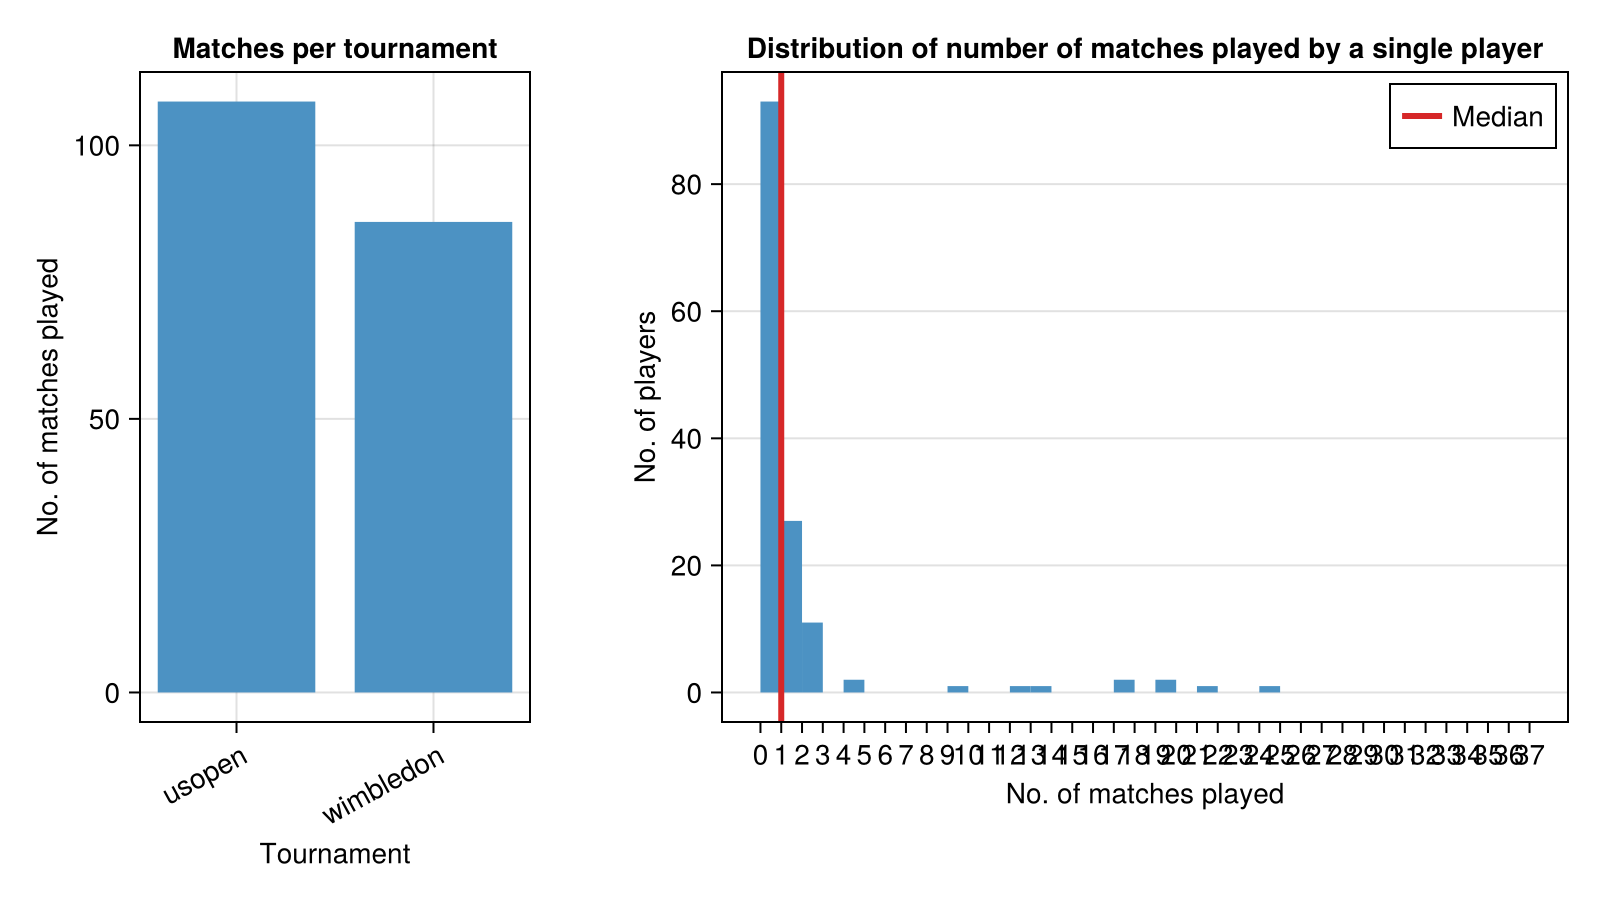

In [481]:
tmnts = categorical([d.Tmnt[1] for d in groupby(df, :match_id)])
tmnt_counts = countmap(tmnts)

f = Figure(size = (800, 450))

ax1 = Axis(f[1,1], 
    xticklabelrotation = 0.5,
    title = "Matches per tournament",
    ylabel = "No. of matches played",
    xlabel = "Tournament",
    xticks = (1:2, String.(levels(tmnts))),
)
barplot!(
    levelcode.(tmnt_counts |> keys), 
    tmnt_counts |> values |> collect
)

npg = values(player_games) .- 1
npg_range = collect(range(extrema(npg)...))
hist_step = 1
ax2 = Axis(f[1,2],
    title = "Distribution of number of matches played by a single player",
    xlabel = "No. of matches played",
    ylabel = "No. of players",
    xgridvisible = false,
    xticks = npg_range,
)

bins = [range(extrema(npg)...)...]
plt = hist!(npg |> collect, bins = bins)
vlines!(median(npg) + 1, ymin = 0, color = tab10[4], linewidth = 3, label = "Median")
axislegend(position = :rt)

colsize!(f.layout, 1, Aspect(1, 3/5))
colsize!(f.layout, 2, Auto(0.7))
colgap!(f.layout, 50)
resize_to_layout!(f)

f

In [482]:
CairoMakie.save(joinpath("figs", "tmnt_player_freq.png"), f)

In [399]:
sum(skipmissing(df.ServerId) .== 1496)

0

In [459]:
combine(groupby(df, :player2id), :match_id => length ∘ unique)

Row,player2id,match_id_length_unique
,Int64?,Int64
1,151,7
2,378,1
3,451,1
4,610,1
5,718,1
6,1332,2
7,1410,1
8,1466,1
9,1609,1


In [454]:
player_games

Dict{Int64, Int64} with 18 entries:
  610  => 1
  1685 => 1
  718  => 1
  486  => 1
  623  => 1
  451  => 1
  1618 => 1
  1702 => 1
  681  => 1
  972  => 1
  1466 => 1
  151  => 16
  490  => 2
  378  => 1
  1332 => 2
  1609 => 1
  142  => 2
  1410 => 1

In [409]:
players[players.id .∈ Ref(unique(keys(player_games))), :]

Row,player,id
,String31,Int64
1,Alexander Zverev,145
2,Alexandre Muller,150
3,Carlos Alcaraz,351
4,Frances Tiafoe,623
5,Holger Rune,713
6,Jan Lennard Struff,828
7,Lloyd Harris,1055
8,Novak Djokovic,1332
9,Sebastian Baez,1582


In [405]:
player_games

Dict{Int64, Int64} with 9 entries:
  713  => 1
  828  => 1
  1582 => 1
  1332 => 2
  145  => 1
  623  => 2
  351  => 10
  1055 => 1
  150  => 1

In [219]:
players[players.id .== 1496,:]

Row,player,id
,String31,Int64
1,Roger Federer,1496


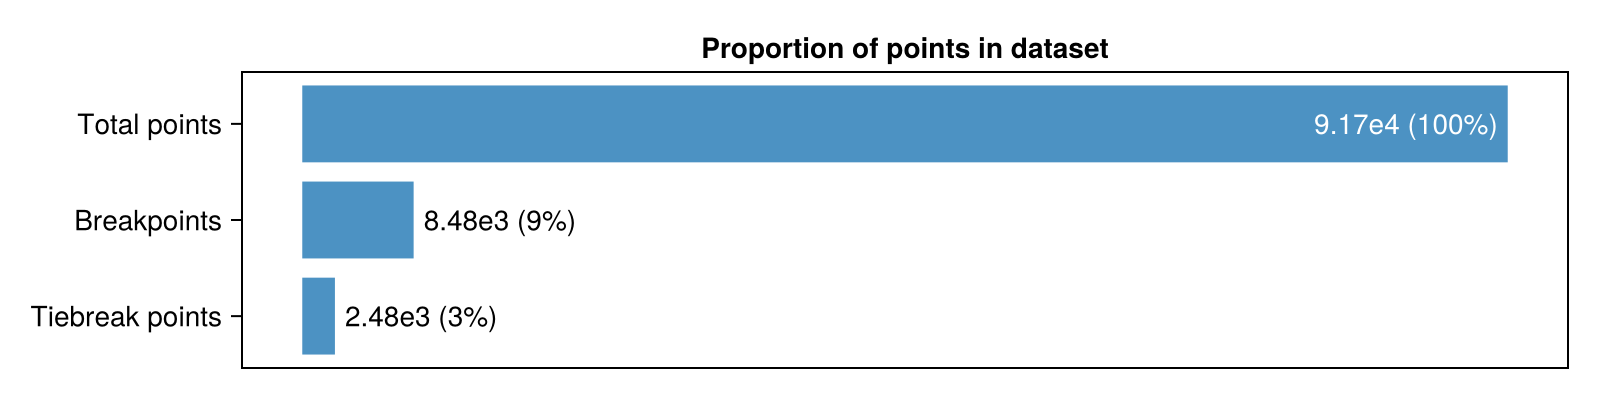

In [197]:
n_games = nrow(df)
n_bp = nrow(df[df.BreakPoint,:])
n_tb = nrow(df[df.Tiebreaker,:])
bars = [n_games, n_bp, n_tb]
labels = [
    replace(
        @sprintf("%.2e (%.2d%%)", b, round(100 * b/n_games, sigdigits=2)),
        r"e\+0" => "e"
    ) for b in bars
]

plt = barplot(
    [3,2,1],
    bars,
    axis = (
        title = "Proportion of points in dataset",
        yticks = (1:3, ["Tiebreak points", "Breakpoints", "Total points"]),
        xticksvisible = false,
        xticklabelsvisible = false,
        xgridvisible = false,
        ygridvisible = false,
    ),
    bar_labels = labels,
    direction = :x,
    figure = (
        size = (800, 200),
    ),
    color_over_bar = :white,
    flip_labels_at = 0.85 * n_games,
)

In [175]:
CairoMakie.save(joinpath("figs", "pointprops.png"), plt)

## Histogram of win probabilities

In [364]:
gdf = groupby(df, [:match_id]);

In [365]:
pws = zeros(length(gdf))
bpws = zeros(Union{Float64, Missing}, length(gdf))
for (i,g) in enumerate(gdf)
    gbp = g[g.BreakPoint,:]
    bpsw = mean(gbp.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    bpws[i] = bpsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, bpws);
# filter!((!) ∘ iszero, bps);

In [201]:
println("Server wins:")
println("Mean: $(mean(pws))")
println("SD: $(std(pws))\n")

println("Breakpoint server wins:")
println("Mean: $(mean(bpws))")
println("SD: $(std(bpws))")

Server wins:
Mean: 0.6062072971716174
SD: 0.05795580564020596

Breakpoint server wins:
Mean: 0.5615589623770565
SD: 0.14833042676742791


In [367]:
df.ServerId |> unique

10-element Vector{Int64}:
 1840
 1841
 1842
 1843
 1844
 1845
 1846
 1847
 1848
 1849

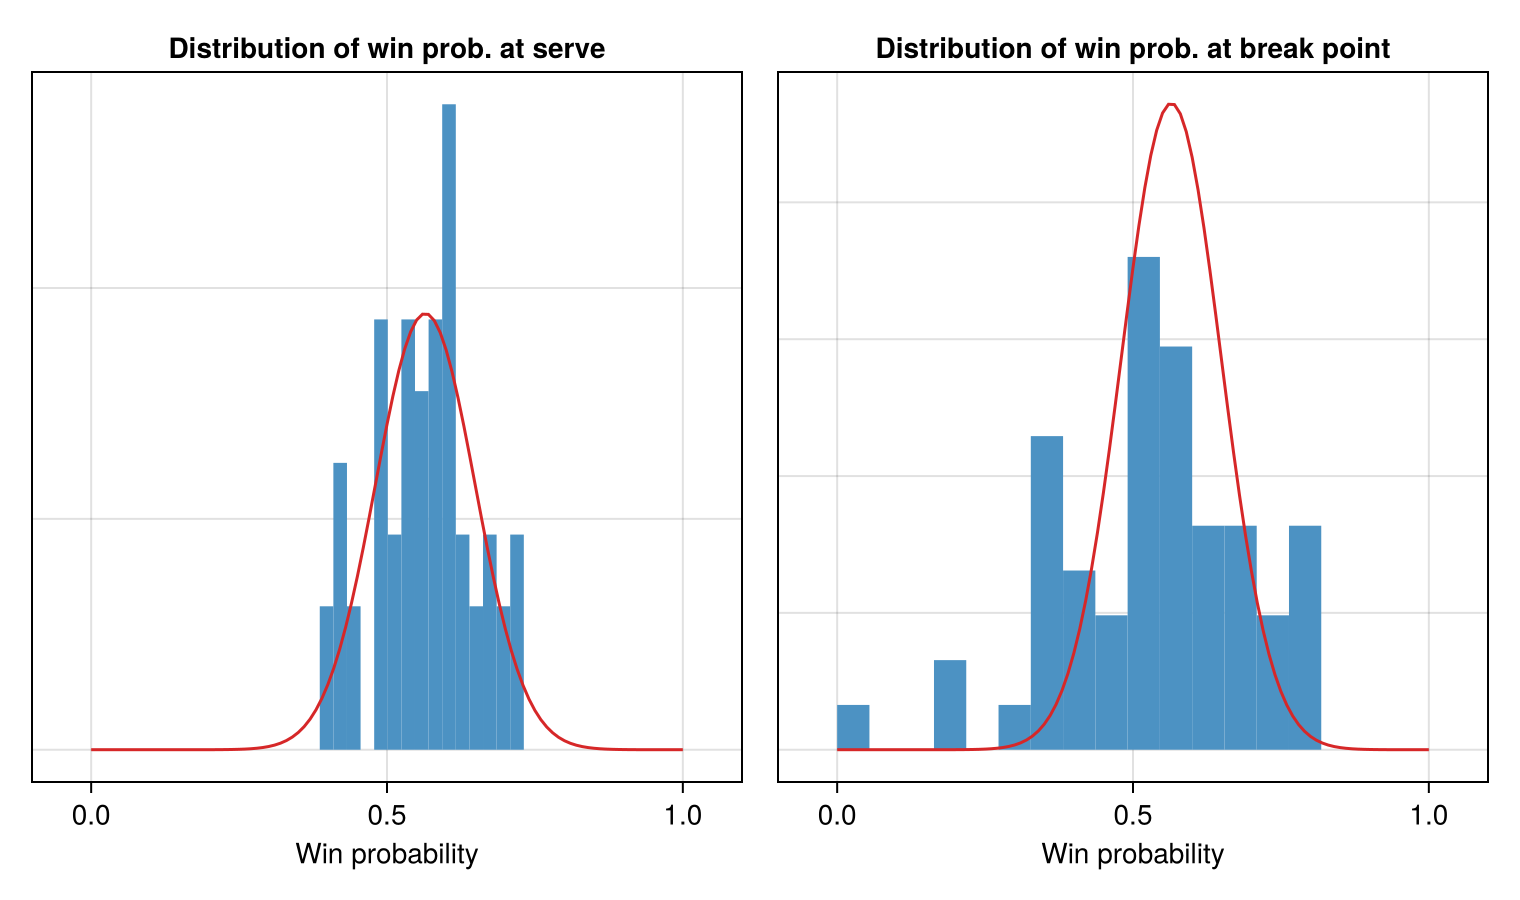

In [366]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at break point")
hist!(bpws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [271]:
mean(bpws)

0.6778054971988796

In [165]:
CairoMakie.save("figs/win_prob_hists.png", f)

In [166]:
pws = zeros(length(gdf))
tbws = zeros(length(gdf))
for (i,g) in enumerate(gdf)
    gtb = g[g.Tiebreaker,:]
    tbsw = mean(gtb.ServerWon)
    
    pwi = g.PointWinner .!= 0
    gpw = g[pwi,:]
    spw = mean(gpw.ServerWon)
    pws[i] = spw
    tbws[i] = tbsw
end
filter!((!) ∘ isnan, pws);
filter!((!) ∘ isnan, tbws);

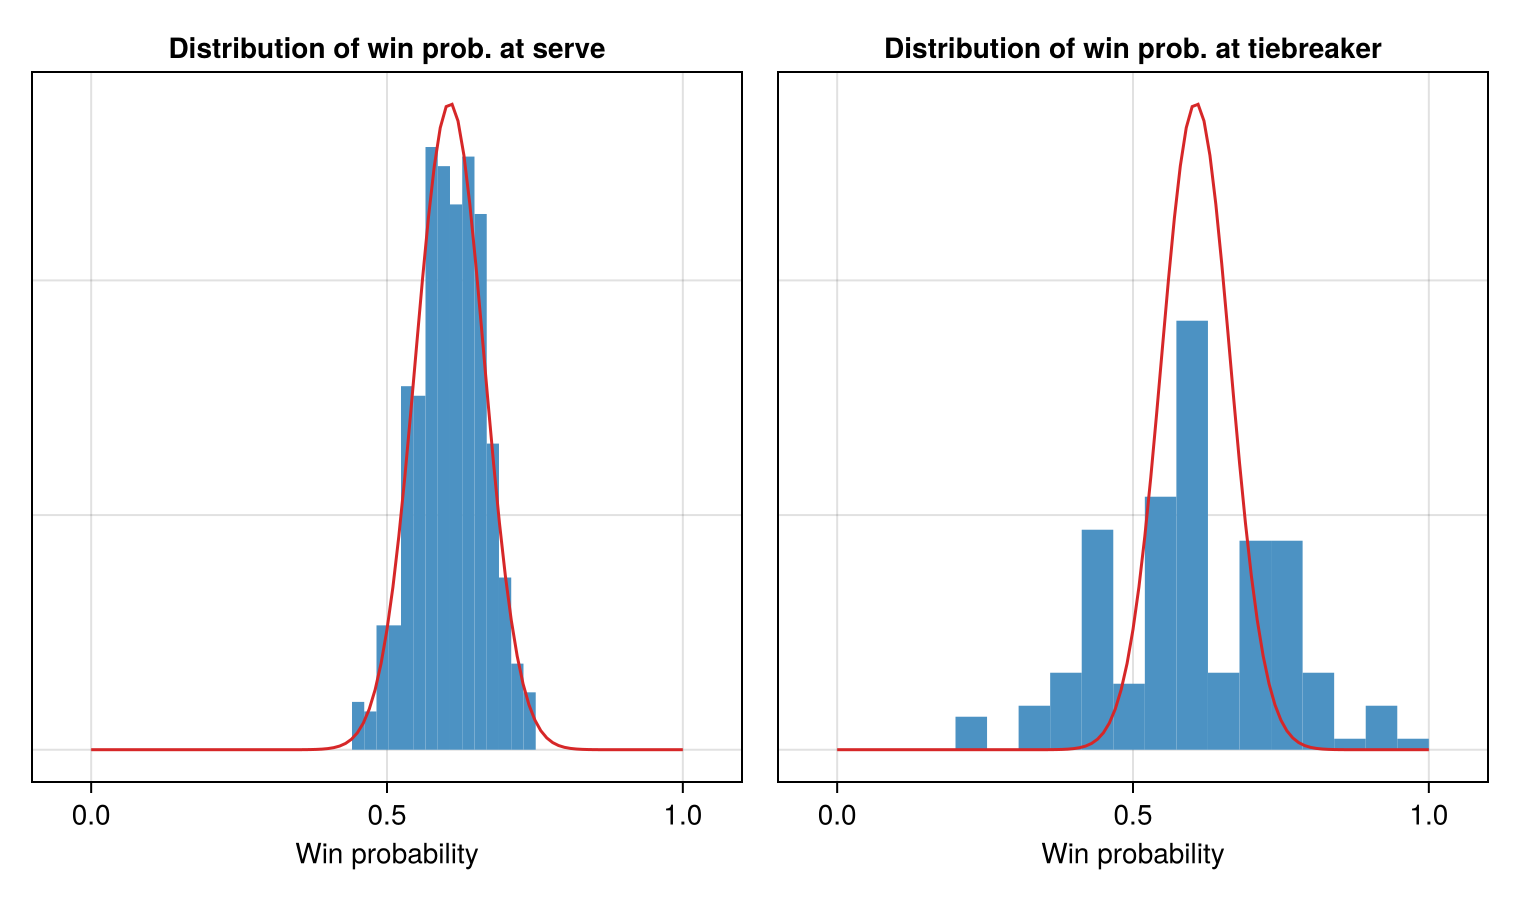

In [167]:
mkax(f; kwargs...) = Axis(f,
    limits = ((-0.1,1.1), nothing);
    aspect = 1,
    xlabel = "Win probability",
    yticksvisible = false,
    yticklabelsvisible = false,
    kwargs...
)
f = Figure()
mkax(f[1,1], title = "Distribution of win prob. at serve")
hist!(pws, normalization = :pdf)
x = 0:0.01:1
y_pws = pdf(fit(Normal, pws), x)
lines!(x,y_pws, color = tab10[4])

mkax(f[1,2], title = "Distribution of win prob. at tiebreaker")
hist!(tbws, normalization = :pdf)
lines!(x,y_pws, color = tab10[4])

for c in 1:2
    colsize!(f.layout, c, Aspect(1,1.0))
end
resize_to_layout!(f)

f

In [168]:
CairoMakie.save("figs/win_prob_tb_hists.png", f)

### Goodness of fit test 

We test the probability that the break point serve win probability distribution is the same as the estimated normal distribution of the win serve win probability. We use the fact that, for $X_i \sim N(0,1)$,
$$
\sum_i^n (X_i - \bar{X})^2 \sim \chi_{n-1}^2 \quad \text{where}\quad 
\bar{X} = \frac{1}{n} \sum_i^n X_i.
$$

In [171]:
d = fit(Normal, pws)
T = sum((tbws .- mean(d)).^2) / var(d)
p_pws = 1 - cdf(Chisq(length(tbws)-1), T)

0.0

Then we also do a Kolmogorov-Smirnov test.

In [170]:
pvalue(ApproximateTwoSampleKSTest(pws, skipmissing(bpws) |> collect))

3.452935708006813e-17